# Code to analyse compression ratio

21-02-2021 Guido Cattani

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import mannwhitneyu as mannwhitneyu

In [2]:
# read compression ratio (CR) data
def read_CR():
    f_in = '/media/guido/LACIE/Cingle_Guido/Master/Compression_ratio.xlsx'
    p_in = Path(f_in)   
    df = pd.read_excel(p_in, sheet_name='CR', header=0, nrows=85)
    df = df.drop(['Unnamed: 0'], axis=1)
    df = df.fillna(pd.NA)
    return df

In [3]:
# adjust column names, change format columns labels 'f_Hz' to f

data = read_CR()
clmns = data.columns
l = list()
for clm in clmns:
    l.append(clm)
l = l[2:]
l2 = list()
for s in l:
    s = s.rstrip('_Hz')
    f = int(s)
    l2.append(f)
d = dict()
d1 = dict()
for i in range(len(l)):
    d.update({l[i] : l2[i]})
    d1.update({l2[i] : l[i]})
data1 = data.drop(columns='Study_ID') # drop first column
data1 = data1.rename(columns=d)

In [4]:
# group data by device type and perform calculation of quantiles 10, 50, 90
dvc = data1.groupby('Device')
quantiles = [0.10, 0.50, 0.90]
q = dvc.quantile(q=quantiles)

# convert Pandas object in numpy array
frqc = np. array(l2 , dtype=int)
p10_bh5 = q.iloc[0].T.to_numpy()
median_bh5 = q.iloc[1].T.to_numpy()
p90_bh5 = q.iloc[2].T.to_numpy()
p10_bp110 = q.iloc[3].T.to_numpy()
median_bp110 = q.iloc[4].T.to_numpy()
p90_bp110 = q.iloc[5].T.to_numpy()

# select BP110 data and convert the Pandas Dataframe to numpy array
is_bp110 =  data1['Device']=='BP110'
cr_bp110 = data1[is_bp110]
dvc1 = cr_bp110.pop('Device')
bp110 = cr_bp110.T.to_numpy()

# select BAHA5P data and convert the Pandas Dataframe to numpy array
is_baha5p =  data1['Device']=='BAHA5P'
cr_baha5p = data1[is_baha5p]
dvc2 = cr_baha5p.pop('Device')
bh5 = cr_baha5p.T.to_numpy()

In [5]:
len(cr_bp110)

49

In [6]:
len(cr_baha5p)

36

In [7]:
q

250    315    400    500   630    800    1000   1250   1600  \
Device                                                                     
BAHA5P 0.1  1.020  0.930  0.870  0.895  0.89  0.895  0.920  0.930  0.935   
       0.5  1.115  1.115  1.035  0.950  0.93  0.930  0.950  0.975  0.995   
       0.9  1.225  1.290  1.180  1.080  1.05  1.005  0.995  1.055  1.090   
BP110  0.1  0.998  0.960  0.970  0.990  0.99  0.990  1.010  0.990  0.960   
       0.5  1.100  1.030  1.040  1.050  1.05  1.040  1.030  1.010  0.990   
       0.9  1.474  1.350  1.280  1.158  1.15  1.104  1.102  1.060  1.010   

             2000   2500   3150   4000   5000   6300   8000  
Device                                                       
BAHA5P 0.1  0.950  0.930  0.920  0.890  0.890  0.900  0.915  
       0.5  0.995  0.940  0.930  0.920  0.930  0.930  0.950  
       0.9  1.045  0.965  0.940  0.930  0.950  1.005  1.050  
BP110  0.1  0.938  0.930  0.910  0.906  0.910  0.910  0.940  
       0.5  0.960  0.950  0.930  0.930  0.930  0.940  0.970  
       0.9  0.990  0.970  0.952  0.950  0.952  0.960  1.004

In [8]:
# select data columns for violin plot with frequency 1 - 8 kHz  and convert data to numpy arrays

cr_bp110_hf = cr_bp110.drop(columns =[250, 315, 400, 500, 630, 800]) 
cr_baha5p_hf = cr_baha5p.drop(columns =[250, 315, 400, 500, 630, 800]) 
bp110_hf = cr_bp110_hf.to_numpy()
bh5_hf = cr_baha5p_hf.to_numpy()

In [9]:
# compare distribution cr BAHA5P vs. BP110 with Mann Whitney U test

mwu = dict()

for i in range(0, 16):
    a = cr_baha5p.iloc[:, i]
    b = cr_bp110.iloc[:, i]
    f = l2[i]
    # scipy.stats mannwhitneyu test
    u_statistic, pVal = mannwhitneyu(a , b, use_continuity=False, alternative='two-sided') 
    pVal = round(pVal, 15)
    st = {f: [u_statistic, pVal]}
    mwu.update(st)
u_test = pd.DataFrame.from_dict(mwu, dtype='float')

In [10]:
# join percentiles & U-test and present both in table

q= q.round(decimals=2)
q = q.reset_index()
diq = {0:'BAHA5P P10', 1:'BAHA5P P50', 2:'BAHA5P P90', 
      3:'BP110 P10', 4:'BP110 P50', 5:'BP110 P90'} 

q = q.rename(index=diq)
q = q.drop(['Device', 'level_1'], axis=1)

diu =  {0: 'Mann-Whitney U statistic', 1: 'p-value (two-sided)'}
u_test = u_test.rename(index=diu)
u_test

analysis_cr = pd.concat([q, u_test])

analysis_cr = analysis_cr.rename(columns=d1)

# write to xlsx file
analysis_cr.to_excel("/media/guido/LACIE/Cingle_Guido/Analysis_results/analysis_compressio_ratio.xlsx",
                         sheet_name='cr_BAHA5_vs_BP110')  

analysis_cr

,250_Hz,315_Hz,400_Hz,500_Hz,630_Hz,800_Hz,1000_Hz,1250_Hz,1600_Hz,2000_Hz,2500_Hz,3150_Hz,4000_Hz,5000_Hz,6300_Hz,8000_Hz
BAHA5P P10,1.020000,0.930000,0.870000,9.000000e-01,8.900000e-01,9.000000e-01,9.200000e-01,0.930000,0.940000,0.950000,0.930000,0.920000,0.890000,0.890000,0.900000,0.920000
BAHA5P P50,1.120000,1.120000,1.040000,9.500000e-01,9.300000e-01,9.300000e-01,9.500000e-01,0.980000,1.000000,1.000000,0.940000,0.930000,0.920000,0.930000,0.930000,0.950000
BAHA5P P90,1.230000,1.290000,1.180000,1.080000e+00,1.050000e+00,1.000000e+00,1.000000e+00,1.060000,1.090000,1.040000,0.960000,0.940000,0.930000,0.950000,1.000000,1.050000
BP110 P10,1.000000,0.960000,0.970000,9.900000e-01,9.900000e-01,9.900000e-01,1.010000e+00,0.990000,0.960000,0.940000,0.930000,0.910000,0.910000,0.910000,0.910000,0.940000
BP110 P50,1.100000,1.030000,1.040000,1.050000e+00,1.050000e+00,1.040000e+00,1.030000e+00,1.010000,0.990000,0.960000,0.950000,0.930000,0.930000,0.930000,0.940000,0.970000
BP110 P90,1.470000,1.350000,1.280000,1.160000e+00,1.150000e+00,1.100000e+00,1.100000e+00,1.060000,1.010000,0.990000,0.970000,0.950000,0.950000,0.950000,0.960000,1.000000
Mann-Whitney U statistic,892.000000,1001.500000,638.000000,2.245000e+02,1.940000e+02,1.290000e+02,6.950000e+01,522.500000,1013.500000,1310.500000,744.500000,716.000000,508.500000,671.500000,713.000000,755.500000
p-value (two-sided),0.929036,0.287489,0.029701,4.841126e-09,9.067270e-10,2.000500e-11,4.470000e-13,0.001324,0.240054,0.000126,0.213188,0.126173,0.000703,0.057547,0.129918,0.258522


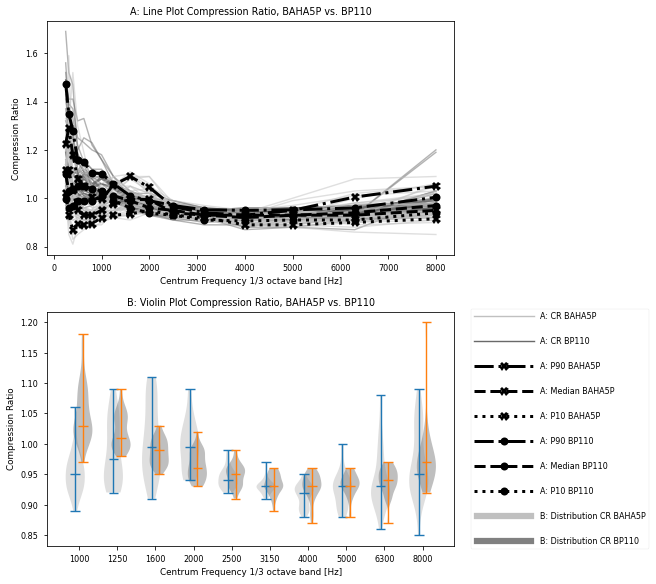

In [11]:
# make a figure to plot otput baha5 vs. BP110

plt.style.use('seaborn-paper')
plt.rcParams['axes.facecolor'] = 'white'

fig, (ax, ax1) = plt.subplots(2, constrained_layout=True)

fig.set_figheight(8)
fig.set_figwidth(9)


# make the line plot

ax.set(xlabel='Centrum Frequency 1/3 octave band [Hz]', ylabel='Compression Ratio',
       title='A: Line Plot Compression Ratio, BAHA5P vs. BP110')

# plot lines based on numpy arrays
ax.plot(frqc, bp110, color="dimgrey", alpha=0.5, label='cr FL BP110')
ax.plot(frqc, bh5, color="silver", alpha=0.5, label='cr FL BAHA5P')
ax.plot(frqc, median_bp110, color='black', marker='o', linestyle='dashed', linewidth=3, markersize=8)
ax.plot(frqc, p10_bp110, color='black', marker='o', linestyle='dotted', linewidth=3, markersize=8)
ax.plot(frqc, p90_bp110, color='black', marker='o', linestyle='dashdot', linewidth=3, markersize=8)
ax.plot(frqc, median_bh5, color='black', marker='X', linestyle='dashed', linewidth=3, markersize=9)
ax.plot(frqc, p10_bh5, color='black', marker='X', linestyle='dotted', linewidth=3, markersize=9)
ax.plot(frqc, p90_bh5, color='black', marker='X', linestyle='dashdot', linewidth=3, markersize=9)


# make the violin plot

xi = list(range(1, 11))
x = list(cr_bp110_hf.columns)


ax1.set(xlabel='Centrum Frequency 1/3 octave band [Hz]', ylabel='Compression Ratio', 
        title='B: Violin Plot Compression Ratio, BAHA5P vs. BP110')

ax1.set_xticks(xi)
ax1.set_xticklabels(x)

viol1 = ax1.violinplot(bh5_hf, positions=[0.9, 1.9, 2.9, 3.9, 4.9, 5.9, 6.9, 7.9, 8.9, 9.9], 
                       showmeans=False, showmedians=True, showextrema=True)

for pc in viol1['bodies']:
    pc.set_facecolor('silver')
    pc.set_alpha(0.5)


viol2 = ax1.violinplot(bp110_hf, positions=[1.1, 2.1, 3.1, 4.1, 5.1, 6.1, 7.1, 8.1, 9.1, 10.1], 
                       showmeans=False, showmedians=True, showextrema=True)

for pc in viol2['bodies']:
    pc.set_facecolor('grey')
    pc.set_alpha(0.5)

    
# make a legend
leg_line_BH5 = mlines.Line2D([], [], color="silver", label='A: CR BAHA5P')
leg_line_BP110 = mlines.Line2D([], [], color="dimgrey", label='A: CR BP110')

leg_p90_bh5 = mlines.Line2D([], [], color='black', marker='X', linestyle='dashdot', 
                            linewidth=3, markersize=9, label='A: P90 BAHA5P')
leg_med_bh5 = mlines.Line2D([], [], color='black', marker='X', linestyle='dashed', 
                            linewidth=3, markersize=9, label='A: Median BAHA5P')
leg_p10_bh5 = mlines.Line2D([], [], color='black', marker='X', linestyle='dotted', 
                            linewidth=3, markersize=9, label='A: P10 BAHA5P')
leg_p90_bp110 = mlines.Line2D([], [], color='black', marker='o', linestyle='dashdot', 
                              linewidth=3, markersize=8, label='A: P90 BP110')
leg_med_bp110 = mlines.Line2D([], [], color='black', marker='o', linestyle='dashed', 
                              linewidth=3, markersize=8, label='A: Median BP110')
leg_p10_bp110 = mlines.Line2D([], [], color='black', marker='o', linestyle='dotted', 
                              linewidth=3, markersize=8, label='A: P10 BP110')
leg_patch_BH5 = mpatches.Patch(color="silver", label='B: Distribution CR BAHA5P')
leg_patch_BP110 = mpatches.Patch(color="grey", label='B: Distribution CR BP110')      

leg = plt.legend(handles=[leg_line_BH5, leg_line_BP110, leg_p90_bh5, leg_med_bh5, leg_p10_bh5, leg_p90_bp110, 
                        leg_med_bp110, leg_p10_bp110, leg_patch_BH5, leg_patch_BP110], 
                 bbox_to_anchor=(1.03, 1.03), loc='upper left', labelspacing=2., handlelength=7.5)


# save figure to file
plt.savefig('/media/guido/LACIE/Cingle_Guido/Analysis_results/compression_ratio.tiff', 
           transparent=False, dpi=500, bbox_inches="tight")

plt.show() # show the figure